In [600]:
from read_model_runs import read_model_runs

question_long_df, model_wide_df, question_wide_df, firac_order, model_order = read_model_runs('../data/processed/model-runs')

# Filtrar apenas as linhas em português
question_long_df = question_long_df[question_long_df["language"] == "portuguese"].copy()

print('shape', question_long_df.shape)

question_long_df.head()


shape (26255, 30)


,model_name,firac,language,is_correct,pdf_filename,question_id,materia,oab_test_id,oab_question_id,chosen_option,...,D,full_response,Facts,Issue,Rule,Application,Conclusion,rule_count,fact_count,response_time_seconds
0,gemini-2.0-flash-lite,FILA_,portuguese,True,oab-153.pdf,oab-153.pdf-007,DIREITO CIVIL,II,7,C,...,cada herdeiro pode ser demandado pela dívida t...,"{\n ""F"":[\n ""A existência de um regime de sol...",['A existência de um regime de solidariedade p...,Qual a correta aplicação das regras do regime ...,"Art. 276 do Código Civil, Art. 279 do Código C...",Ao analisar a responsabilidade em caso de fale...,A alternativa C está correta. Em caso de perda...,4,5,4.855925
1,gemini-2.0-flash-lite,FILA_,portuguese,True,oab-153.pdf,oab-153.pdf-014,DIREITO CIVIL,II,14,D,...,"a obrigação poderá ser resolvida, com a devolu...","{\n ""F"":[\n ""João prometeu transferir a propr...",['João prometeu transferir a propriedade de um...,Qual o regime jurídico aplicável à obrigação d...,Art. 235 do Código Civil,"Considerando que uma coisa certa, objeto de pr...","De acordo com o artigo 235 do Código Civil, no...",1,3,2.210483
2,gemini-2.0-flash-lite,FILA_,portuguese,True,oab-154.pdf,oab-154.pdf-019,DIREITO CIVIL,XV,19,B,...,Tatiana e Sandro têm o dever de indenizar Rica...,"{\n ""F"":[\n ""Tatiana causou prejuízos aos veí...",['Tatiana causou prejuízos aos veículos de San...,Quem deve indenizar os prejuízos causados aos ...,"TJ/RS. Recurso Cível Nº 71004670121, Primeira ...",A responsabilidade civil pelos danos causados ...,NaN,1,7,3.379789
3,gemini-2.0-flash-lite,FILA_,portuguese,True,oab-154.pdf,oab-154.pdf-021,DIREITO CIVIL,XV,21,A,...,É permitido ao juiz afastar os efeitos da pers...,"{\n ""F"":[\n ""Paulo foi casado com Luana, por ...","['Paulo foi casado com Luana, por muitos anos,...",É possível desconsiderar os atos de um dos côn...,"Art. 1.660 do Código Civil, Art. 186 do Código...",A conduta de transferir bens particulares para...,"A alternativa correta é a A, pois está alinhad...",4,5,4.220250
4,gemini-2.0-flash-lite,FILA_,portuguese,True,oab-154.pdf,oab-154.pdf-023,DIREITO CIVIL,XV,23,D,...,Todo o patrimônio de Mateus caberá a Alberto.,"{\n ""F"": [\n ""Mateus não possuía outros paren...","['Mateus não possuía outros parentes, não tinh...",Diante da descoberta de um filho após a elabor...,Art. 1.973 do Código Civil,"A regra aplicável estabelece que, se um descen...",D,1,7,2.465413


In [601]:
firac_order

['FILA_', 'FIR__', 'F____', 'FI___', 'FIL__', '_____']

In [602]:
model_order

['gemini-2.5-flash-lite',
 'gemini-2.0-flash-lite',
 'gemma-3-27b-it',
 'gemma-3n-e4b-it',
 'gemma-3-12b-it',
 'gemma-3n-e2b-it',
 'gemma-3-4b-it']

In [603]:
question_long_df.shape

(26255, 30)

Existe missing data?

In [604]:
question_long_df.isna().sum()


model_name                  0
firac                       0
language                    0
is_correct                  0
pdf_filename                0
question_id                 0
materia                     0
oab_test_id                 0
oab_question_id             0
chosen_option               0
correct_option              0
enunciado                   0
prompt                      0
finish_reason               0
avg_logprobs                0
input_token_count           0
output_token_count          0
A                           0
B                          13
C                           0
D                           0
full_response               0
Facts                       0
Issue                       5
Rule                        0
Application              2367
Conclusion               6301
rule_count                  0
fact_count                  0
response_time_seconds       0
dtype: int64

In [605]:
question_long_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26255 entries, 0 to 26254
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   model_name             26255 non-null  object 
 1   firac                  26255 non-null  object 
 2   language               26255 non-null  object 
 3   is_correct             26255 non-null  bool   
 4   pdf_filename           26255 non-null  object 
 5   question_id            26255 non-null  object 
 6   materia                26255 non-null  object 
 7   oab_test_id            26255 non-null  object 
 8   oab_question_id        26255 non-null  int64  
 9   chosen_option          26255 non-null  object 
 10  correct_option         26255 non-null  object 
 11  enunciado              26255 non-null  object 
 12  prompt                 26255 non-null  object 
 13  finish_reason          26255 non-null  object 
 14  avg_logprobs           26255 non-null  float64
 15  in

In [606]:
import pandas as pd

# tabela de contagem
finish_reason_pct = (
    question_long_df
    .pivot_table(index="model_name", columns="finish_reason", aggfunc="size", fill_value=0)
)

# converte para percentuais linha a linha
finish_reason_pct = finish_reason_pct.div(finish_reason_pct.sum(axis=1), axis=0) * 100

finish_reason_pct


finish_reason,STOP
model_name,
gemini-2.0-flash-lite,100.0
gemini-2.5-flash-lite,100.0
gemma-3-12b-it,100.0
gemma-3-27b-it,100.0
gemma-3-4b-it,100.0
gemma-3n-e2b-it,100.0
gemma-3n-e4b-it,100.0


In [ ]:
import pandas as pd

# garantir que model_name seja categórico com ordem definida pela lista model_order
question_long_df["model_name"] = pd.Categorical(
    question_long_df["model_name"],
    categories=model_order,
    ordered=True
)

# Pivot: média de acurácia e contagem de exemplos por modelo
question_wide_df = question_long_df.pivot_table(
    index="model_name",
    columns="firac",
    values="is_correct",
    aggfunc="mean"
).reindex(columns=firac_order)

# Adicionar a coluna count
count_df = question_long_df.groupby("model_name")["question_id"].count().rename("count")

# Juntar o count ao pivot
question_wide_df = question_wide_df.merge(count_df, on="model_name", how="left")

# Resetar índice para model_name virar coluna (mantendo ordem definida)
question_wide_df = question_wide_df.reset_index()


question_wide_df.head(100)


C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\145596347.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  question_wide_df = question_long_df.pivot_table(
C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\145596347.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df = question_long_df.groupby("model_name")["question_id"].count().rename("count")


,model_name,FILA_,FIR__,F____,FI___,FIL__,_____,count
0,gemini-2.5-flash-lite,1.000000,0.938776,0.636364,0.821990,0.848341,0.759434,939
1,gemini-2.0-flash-lite,0.981132,NaN,NaN,0.802548,0.815287,0.787097,628
2,gemma-3-27b-it,0.979073,0.905011,0.718254,0.685256,0.693585,0.634409,6863
3,gemma-3n-e4b-it,0.937074,0.785714,0.727273,0.576923,0.546490,0.529221,3103
4,gemma-3-12b-it,0.971599,0.882086,0.666667,0.648462,0.658333,0.588281,6812
5,gemma-3n-e2b-it,0.893401,0.773381,0.666667,0.450704,0.558824,0.452489,1242
6,gemma-3-4b-it,0.839968,0.713190,0.518868,0.513825,0.490137,0.461952,6668


In [608]:
import pandas as pd

pd.set_option("display.max_rows", None)


# Pivot: média de acurácia por modelo + matéria
question_wide_df = question_long_df.pivot_table(
    index=["model_name", "materia"],   # <-- agora dupla chave
    columns="firac",
    values="is_correct",
    aggfunc="mean"
).reindex(columns=firac_order)

# Adicionar a coluna count
count_df = (
    question_long_df
        .groupby(["model_name", "materia"])["question_id"]  # <-- agora agrupa por ambos
        .count()
        .rename("count")
)

# Juntar o count ao pivot
question_wide_df = question_wide_df.merge(
    count_df,
    on=["model_name", "materia"],   # <-- join pela tupla
    how="left"
)

# Resetar índice (opcional — remove se preferir multiindex na saída)
question_wide_df = question_wide_df.reset_index()

question_wide_df.head(100)


C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\339788905.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  question_wide_df = question_long_df.pivot_table(
C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\339788905.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["model_name", "materia"])["question_id"]  # <-- agora agrupa por ambos


,model_name,materia,FILA_,FIR__,F____,FI___,FIL__,_____,count
0,gemma-3-27b-it,DIREITO AMBIENTAL,1.000000,1.000000,1.000000,0.850000,0.883721,0.837838,210
1,gemma-3-27b-it,DIREITO CIVIL,0.977901,0.877095,0.628571,0.707865,0.703911,0.638889,967
2,gemma-3-27b-it,DIREITO CONSTITUCIONAL,0.979592,0.918367,0.769231,0.673469,0.698980,0.653061,993
3,gemma-3-27b-it,DIREITO DO CONSUMIDOR,0.977273,0.954545,0.916667,0.886364,0.930233,0.840909,231
4,gemma-3-27b-it,DIREITO DO TRABALHO,0.967213,0.862637,NaN,0.554945,0.598901,0.528090,907
5,gemma-3-27b-it,DIREITO EMPRESARIAL,0.988636,0.868132,0.666667,0.696629,0.648352,0.584270,457
6,gemma-3-27b-it,DIREITO INTERNACIONAL,1.000000,0.880952,0.615385,0.682927,0.658537,0.585366,233
7,gemma-3-27b-it,DIREITO TRIBUTÁRIO,0.984496,0.861538,0.645161,0.656000,0.685039,0.620968,666
8,gemma-3-27b-it,DIREITOS HUMANOS,0.982143,0.964286,0.870968,0.890909,0.854545,0.854545,308
9,gemma-3-27b-it,ECA,0.978261,0.931818,0.666667,0.764706,0.804878,0.705882,208


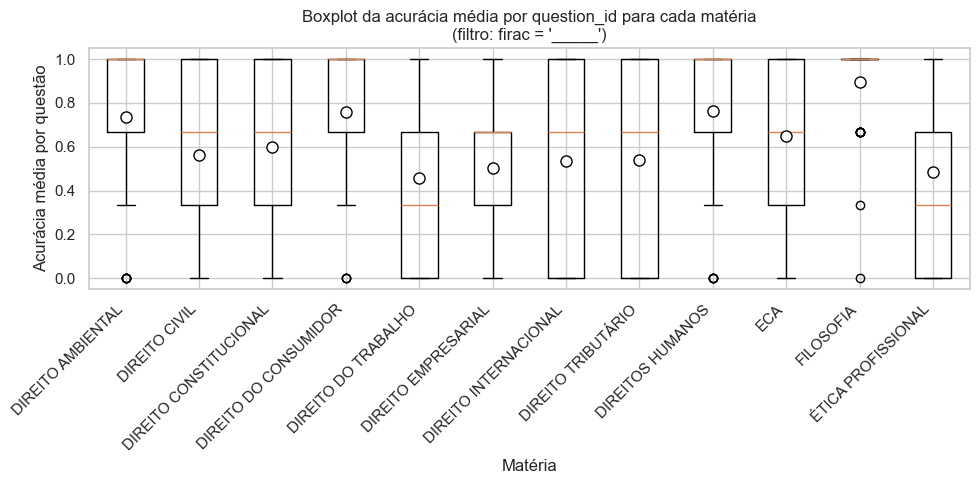

In [609]:
import pandas as pd
import matplotlib.pyplot as plt

# cria coluna numérica de acurácia (1 se acertou, 0 se errou)
question_long_df["accuracy"] = question_long_df["is_correct"].astype(int)

# filtrar apenas firac == '_____'
df_sub = question_long_df.loc[question_long_df["firac"] == "_____"]

# calcula média de acurácia por questão e por materia
acc_by_question = (
    df_sub
    .groupby(["question_id", "materia"])["accuracy"]
    .mean()
    .reset_index()
)

# prepara os dados para o boxplot
unique_materias = sorted(acc_by_question["materia"].unique())

data_to_plot = [
    acc_by_question[acc_by_question["materia"] == m]["accuracy"].values
    for m in unique_materias
]

plt.figure(figsize=(10, 5))

plt.boxplot(
    data_to_plot,
    showmeans=True,
    meanline=False,
    meanprops={
        "marker": "o",
        "markeredgecolor": "black",
        "markersize": 8,
        "markerfacecolor": "white"
    }
)

plt.xticks(
    ticks=range(1, len(data_to_plot) + 1),
    labels=unique_materias,
    rotation=45,
    ha="right"
)

plt.xlabel("Matéria")
plt.ylabel("Acurácia média por questão")
plt.title("Boxplot da acurácia média por question_id para cada matéria\n(filtro: firac = '_____')")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# cria coluna numérica de acurácia (1 se acertou, 0 se errou)
question_long_df["accuracy"] = question_long_df["is_correct"].astype(int)

# filtrar apenas firac == '_____'
df_sub = question_long_df.loc[question_long_df["firac"] == "_____"]

# calcula média de acurácia por questão, por materia e rule_count
acc_by_question = (
    df_sub
    .groupby(["question_id", "materia", "rule_count"])["accuracy"]
    .mean()
    .reset_index()
)

# materias únicas
materias = sorted(acc_by_question["materia"].unique())

# cria subplots, um por matéria
fig, axes = plt.subplots(nrows=len(materias), ncols=1, figsize=(10, 5 * len(materias)))

# se houver apenas 1 matéria, transforma axes em lista
if len(materias) == 1:
    axes = [axes]

for ax, materia in zip(axes, materias):
    data_m = acc_by_question[acc_by_question["materia"] == materia]
    unique_rules = sorted(data_m["rule_count"].unique())
    
    data_to_plot = [
        data_m[data_m["rule_count"] == rc]["accuracy"].values
        for rc in unique_rules
    ]
    
    ax.boxplot(
        data_to_plot,
        showmeans=True,
        meanline=False,
        meanprops={
            "marker": "o",
            "markeredgecolor": "black",
            "markersize": 8,
            "markerfacecolor": "white"
        }
    )
    
    ax.set_title(f"Matéria: {materia} — Acurácia por rule_count", fontsize=12)
    ax.set_xticks(range(1, len(unique_rules) + 1))
    ax.set_xticklabels(unique_rules)
    ax.set_xlabel("rule_count")
    ax.set_ylabel("Acurácia média por questão")

plt.tight_layout()
plt.show()


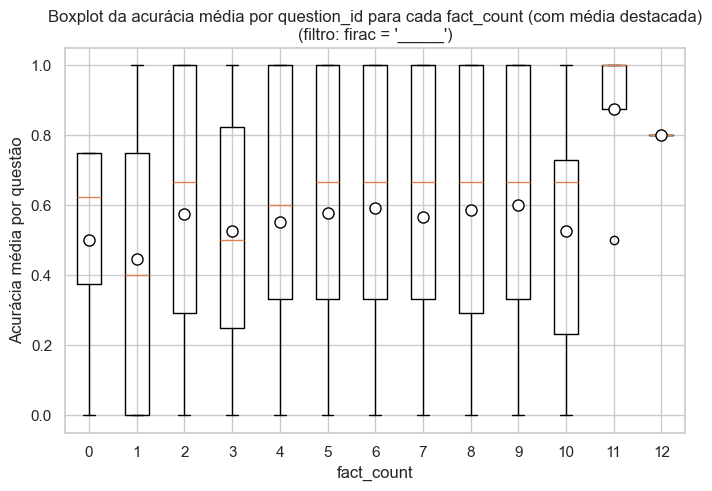

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# cria coluna numérica de acurácia (1 se acertou, 0 se errou)
question_long_df["accuracy"] = question_long_df["is_correct"].astype(int)

# filtrar apenas firac == '_____'
df_sub = question_long_df.loc[question_long_df["firac"] == "_____"]

# calcula média de acurácia por questão e por fact_count
acc_by_question = (
    df_sub
    .groupby(["question_id", "fact_count"])["accuracy"]
    .mean()
    .reset_index()
)

# prepara os dados para o boxplot
unique_facts = sorted(acc_by_question["fact_count"].unique())

data_to_plot = [
    acc_by_question[acc_by_question["fact_count"] == fc]["accuracy"].values
    for fc in unique_facts
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    data_to_plot,
    showmeans=True,   # mostra a média
    meanline=False,   # usa ponto em vez de linha
    meanprops={
        "marker": "o",
        "markeredgecolor": "black",
        "markersize": 8,
        "markerfacecolor": "white"
    }
)

plt.xticks(
    ticks=range(1, len(data_to_plot) + 1),
    labels=unique_facts
)
plt.xlabel("fact_count")
plt.ylabel("Acurácia média por questão")
plt.title("Boxplot da acurácia média por question_id para cada fact_count (com média destacada)\n(filtro: firac = '_____')")

plt.show()


In [ ]:
import pandas as pd


# 2. Criar pivot table: cada linha = question_id, cada coluna = firac, valor = média de is_correct
question_wide_df = question_long_df.pivot_table(
    index="question_id",
    columns="firac",
    values="is_correct",
    aggfunc="mean"
).reindex(columns=firac_order)  # reordenar colunas pela acurácia média global

# 3. Resetar índice se quiser question_id como coluna normal
question_wide_df = question_wide_df.reset_index()

# 4. Mostrar o resultado
question_wide_df.head(100)


firac,question_id,FILA_,FIR__,F____,FI___,FIL__,_____
0,oab-1.pdf-003,1.000000,1.000000,NaN,0.200000,0.400000,0.000000
1,oab-1.pdf-004,1.000000,1.000000,NaN,0.800000,0.833333,0.666667
2,oab-1.pdf-005,0.666667,0.000000,0.666667,1.000000,1.000000,1.000000
3,oab-1.pdf-006,1.000000,1.000000,NaN,0.800000,0.833333,1.000000
4,oab-1.pdf-007,1.000000,1.000000,0.666667,1.000000,0.857143,0.666667
5,oab-1.pdf-008,0.833333,1.000000,NaN,1.000000,0.800000,0.600000
6,oab-1.pdf-009,1.000000,1.000000,0.333333,0.666667,1.000000,0.800000
7,oab-1.pdf-010,1.000000,0.800000,NaN,0.800000,0.500000,0.166667
8,oab-10.pdf-091,1.000000,0.500000,NaN,0.600000,0.400000,0.600000
9,oab-10.pdf-092,1.000000,1.000000,NaN,0.666667,0.600000,NaN


In [ ]:
# -----------------------
# Calcular acurácia, tamanho médio do enunciado, média de rule_count e tempo médio de resposta por questão
# -----------------------
question_agg_df = (
    question_long_df
    .groupby("question_id")
    .agg(
        accuracy=("is_correct", "mean"),
        avg_input_token_count=("input_token_count", lambda x: x.mean()),
        avg_output_token_count=("output_token_count", lambda x: x.mean()),
        avg_rule_count=("rule_count", "mean"),
        avg_fact_count=("fact_count", "mean"),
        avg_response_time_seconds=("response_time_seconds", "mean")
    )
    .reset_index()
)

# Ordenar por accuracy
question_agg_df = question_agg_df.sort_values(by="accuracy", ascending=True).reset_index(drop=True)

# Visualizar as primeiras linhas
question_agg_df.head()


,question_id,accuracy,avg_input_token_count,avg_output_token_count,avg_rule_count,avg_fact_count,avg_response_time_seconds
0,oab-209.pdf-114,0.0,414.333333,0.000000,1.0,5.0,4.808067
1,oab-17.pdf-168,0.0,630.000000,0.000000,2.0,7.0,7.868311
2,oab-172.pdf-199,0.0,682.166667,94.833333,2.0,6.0,7.793395
3,oab-177.pdf-249,0.0,715.500000,0.000000,2.0,7.0,12.286663
4,oab-211.pdf-127,0.0,413.666667,0.000000,2.0,3.0,8.278855


In [ ]:
import pandas as pd
import numpy as np

# 1. Calcular a acurácia média global por firac (para ordenar dificuldade)
firac_difficulty = (
    question_long_df
    .groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# 2. Criar um mapeamento da dificuldade ordinal (0 = mais fácil)
firac_order = {firac: i for i, firac in enumerate(firac_difficulty["firac"])}

# 3. Adicionar a ordem de dificuldade no dataframe original
df = question_long_df.copy()
df["firac_order"] = df["firac"].map(firac_order)

# 4. Função com response_correct_vector e response_option_vector
def guttman_info(df_model):
    df_sorted = df_model.sort_values("firac_order")

    # Vetores ordenados pela dificuldade
    y = df_sorted["is_correct"].values
    chosen = df_sorted["chosen_option"].astype(str).values

    # Inconsistências
    n_inconsistencias = 0
    for i in range(len(y)):
        for j in range(i + 1, len(y)):
            if y[i] < y[j]:
                n_inconsistencias += 1

    # Strings compactas para análise
    response_correct_vector = "".join(str(int(v)) for v in y)
    response_option_vector = "".join(chosen)

    return pd.Series({
        "n_inconsistencias": n_inconsistencias,
        "response_correct_vector": response_correct_vector,
        "response_option_vector": response_option_vector
    })

# 5. Aplicar por modelo e questão
model_guttmann_df = (
    df
    .groupby(["model_name", "question_id"])
    .apply(guttman_info)
    .reset_index()
)

# 6. Ordenar por inconsistências (maior → mais inconsistente, mantém sua escolha)
gutmann_long_df = (
    model_guttmann_df
    .sort_values("n_inconsistencias", ascending=False)
    .reset_index(drop=True)
)

# 7. Visualizar
gutmann_long_df.head(200)


C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\1003435980.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["model_name", "question_id"])
C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\1003435980.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(guttman_info)


,model_name,question_id,n_inconsistencias,response_correct_vector,response_option_vector
0,gemma-3-4b-it,oab-1.pdf-005,9.0,000111,BBBAAA
1,gemma-3-27b-it,oab-104.pdf-058,8.0,001111,DABBBB
2,gemma-3-27b-it,oab-1.pdf-005,8.0,001111,A/BBAAAA
3,gemma-3-12b-it,oab-111.pdf-124,8.0,001011,AACACC
4,gemma-3-27b-it,oab-106.pdf-081,6.0,011011,ADDADD
5,gemma-3-12b-it,oab-152.pdf-082,6.0,00011,DDDAA
6,gemma-3-4b-it,oab-104.pdf-060,6.0,00011,DDDBB
7,gemma-3-27b-it,oab-9.pdf-088,6.0,00011,CCCAA
8,gemma-3-4b-it,oab-154.pdf-024,6.0,00111,DABBB
9,gemma-3-4b-it,oab-319.pdf-222,6.0,00111,BBCCC


In [ ]:
import pandas as pd
import numpy as np

# 1. Calcular a acurácia média global por firac (para ordenar dificuldade)
firac_difficulty = (
    question_long_df
    .groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)  # mais fácil primeiro
    .reset_index()
)

# 2. Criar um mapeamento da dificuldade ordinal (0 = mais fácil, N = mais difícil)
firac_order = {firac: i for i, firac in enumerate(firac_difficulty["firac"])}

# 3. Adicionar a ordem de dificuldade no dataframe original
df = question_long_df.copy()
df["firac_order"] = df["firac"].map(firac_order)

# 4. Função que calcula inconsistências por transição de firac
def guttman_per_firac(df_model):
    df_sorted = df_model.sort_values("firac_order")
    y = df_sorted["is_correct"].values
    firacs = df_sorted["firac"].values
    
    inconsistencias_por_firac = {}
    for i in range(1, len(y)):
        if y[i-1] < y[i]:
            inconsistencias_por_firac[firacs[i]] = inconsistencias_por_firac.get(firacs[i], 0) + 1
        else:
            inconsistencias_por_firac[firacs[i]] = inconsistencias_por_firac.get(firacs[i], 0)
    
    # Transformar em DataFrame long
    df_long = pd.DataFrame({
        "firac": list(inconsistencias_por_firac.keys()),
        "n_inconsistencias": list(inconsistencias_por_firac.values())
    })
    
    df_long["response_vector"] = "".join(str(int(v)) for v in y)
    
    return df_long

# 5. Aplicar por modelo e questão e concatenar resultados
result_list = []

for (model, question), group in df.groupby(["model_name", "question_id"]):
    df_long = guttman_per_firac(group)
    df_long["model_name"] = model
    df_long["question_id"] = question
    result_list.append(df_long)

guttmann_per_firac_df = pd.concat(result_list, ignore_index=True)

# 6. Visualizar resultado
guttmann_per_firac_df.head(20)


C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\4004933534.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (model, question), group in df.groupby(["model_name", "question_id"]):


,firac,n_inconsistencias,response_vector,model_name,question_id
0,FIR__,0.0,11000,gemini-2.5-flash-lite,oab-1.pdf-003
1,FI___,0.0,11000,gemini-2.5-flash-lite,oab-1.pdf-003
2,FIL__,0.0,11000,gemini-2.5-flash-lite,oab-1.pdf-003
3,_____,0.0,11000,gemini-2.5-flash-lite,oab-1.pdf-003
4,FIR__,0.0,11111,gemini-2.5-flash-lite,oab-1.pdf-004
5,FI___,0.0,11111,gemini-2.5-flash-lite,oab-1.pdf-004
6,FIL__,0.0,11111,gemini-2.5-flash-lite,oab-1.pdf-004
7,_____,0.0,11111,gemini-2.5-flash-lite,oab-1.pdf-004
8,FIR__,0.0,10,gemini-2.5-flash-lite,oab-1.pdf-005
9,FIR__,0.0,11111,gemini-2.5-flash-lite,oab-1.pdf-006


In [ ]:
import pandas as pd

# Agrupar por firac e calcular estatísticas
firac_stats_df = (
    guttmann_per_firac_df
    .groupby("firac")["n_inconsistencias"]
    .agg(
        mean_inconsistencias="mean",
        median_inconsistencias="median",
        std_inconsistencias="std"
    )
    .reset_index()
)

# Ordenar por dificuldade se desejar (opcional)
firac_stats_df = firac_stats_df.sort_values("mean_inconsistencias", ascending=False)

# Visualizar resultado
firac_stats_df


,firac,mean_inconsistencias,median_inconsistencias,std_inconsistencias
4,_____,0.092377,0.0,0.289589
0,FIL__,0.076540,0.0,0.265886
2,FI___,0.045349,0.0,0.208092
1,FIR__,0.028732,0.0,0.167070
3,F____,0.027027,0.0,0.162331


C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\1399155143.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_guttmann_df.groupby("model_name")["n_inconsistencias"]
C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\1399155143.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


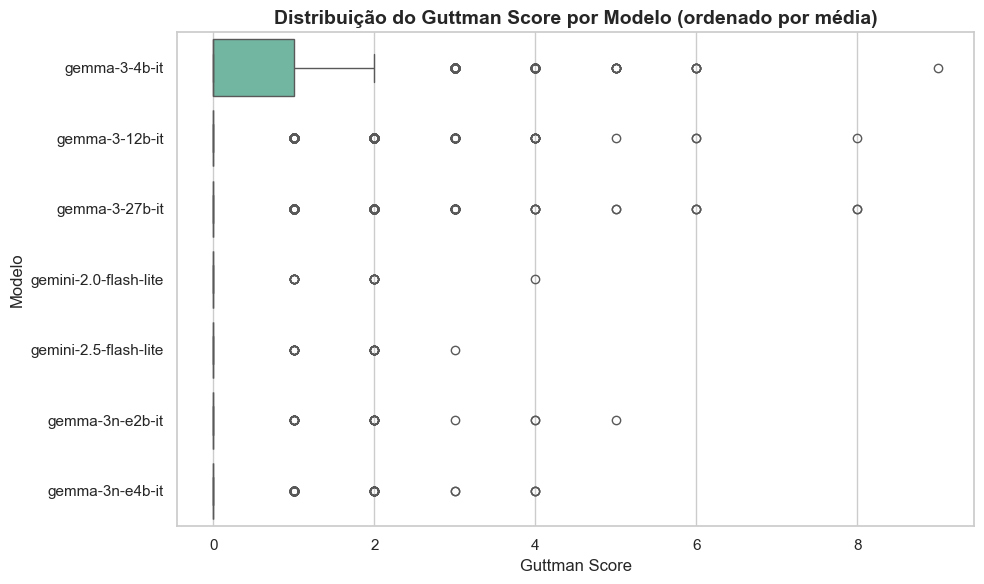

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular a mediana do Guttman score por modelo
mean_order = (
    model_guttmann_df.groupby("model_name")["n_inconsistencias"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# 2. Plotar boxplot ordenado
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

sns.boxplot(
    data=model_guttmann_df,
    y="model_name",
    x="n_inconsistencias",
    order=mean_order,      # ordena do maior pro menor
    palette="Set2",
    orient="h"               # horizontal pra melhor leitura
)

# 3. Ajustes visuais
plt.title("Distribuição do Guttman Score por Modelo (ordenado por média)", fontsize=14, weight='bold')
plt.xlabel("Guttman Score", fontsize=12)
plt.ylabel("Modelo", fontsize=12)
#plt.xlim(0.4, 1.1)  # intervalo pedido
plt.tight_layout()

plt.show()


In [ ]:
# Mostra 'resposta_completa' quando 'alternativa' está vazia ou é NaN
question_long_df.loc[question_long_df['chosen_option'].isna(), 'full_response']


Series([], Name: full_response, dtype: object)

In [ ]:
import pandas as pd

# Supondo que question_long_df já está carregado

# Cálculo da acurácia média por modelo e por firac
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
model_accuracy["model_order"] = range(1, len(model_accuracy) + 1)

firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
firac_accuracy["firac_order"] = range(1, len(firac_accuracy) + 1)

# Exibindo os resultados
print("Model order:")
print(model_accuracy)

print("\nFirac order:")
print(firac_accuracy)

model_order_accuracy = model_accuracy[["model_name"]].values
firac_order_accuracy = firac_accuracy[["firac"]].values




Model order:
              model_name  is_correct  model_order
0          gemma-3-4b-it    0.599482            1
1        gemma-3n-e2b-it    0.690987            2
2         gemma-3-12b-it    0.751047            3
3        gemma-3n-e4b-it    0.779157            4
4         gemma-3-27b-it    0.779386            5
5  gemini-2.0-flash-lite    0.847134            6
6  gemini-2.5-flash-lite    0.863685            7

Firac order:
   firac  is_correct  firac_order
0  _____    0.572003            1
1  FIL__    0.620669            2
2  FI___    0.627965            3
3  F____    0.651116            4
4  FIR__    0.825770            5
5  FILA_    0.935478            6


C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\2776949349.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  question_long_df.groupby("model_name")["is_correct"]


C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\1330520917.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["model_name", "firac"])["is_correct"]
C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\1330520917.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  question_long_df.groupby("model_name")["is_correct"]


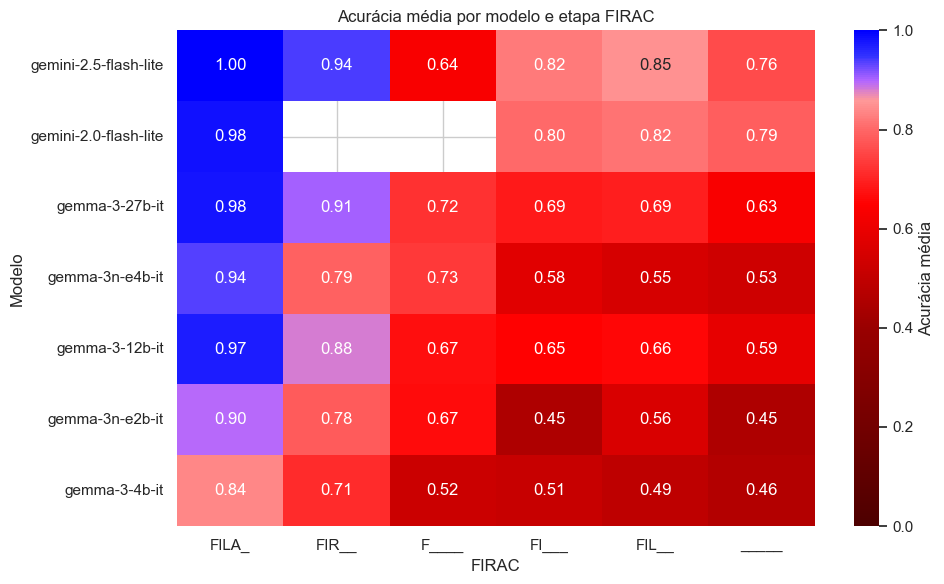

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Calcular acurácia média por modelo e firac
heatmap_data = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .unstack()
)

# 2. Calcular ordem dos modelos e FIRAC
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)
firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

model_order_accuracy = model_accuracy.index.tolist()
firac_order_accuracy = firac_accuracy.index.tolist()

# 3. Reordenar DataFrame
heatmap_data = heatmap_data.loc[model_order_accuracy, firac_order_accuracy]

# 4. Colormap com nuances vermelhas e transição suave após 0.9
custom_cmap = LinearSegmentedColormap.from_list(
    "detailed_red_blue",
    [
        (0.0, "#4d0000"),   # 0.00 = vermelho muito escuro
        (0.4, "#990000"),   # 0.40 = vermelho forte
        (0.65, "#ff0000"),  # 0.65 = vermelho puro
        (0.80, "#ff6666"),  # 0.80 = vermelho claro
        (0.86, "#ff9999"),  # 0.86 = rosado
        (0.90, "#b366ff"),  # 0.90 = começa roxo
        (0.95, "#3333ff"),  # 0.95 = azul forte
        (1.0, "blue")       # 1.00 = azul puro
    ]
)

# 5. Plotar o heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Acurácia média'}
)
plt.title("Acurácia média por modelo e etapa FIRAC")
plt.xlabel("FIRAC")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()


In [ ]:
!pip install adjustText


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\pedro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\19919677.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["model_name", "firac"])["is_correct"]
C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\19919677.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  question_long_df.groupby("model_name")["is_correct"]


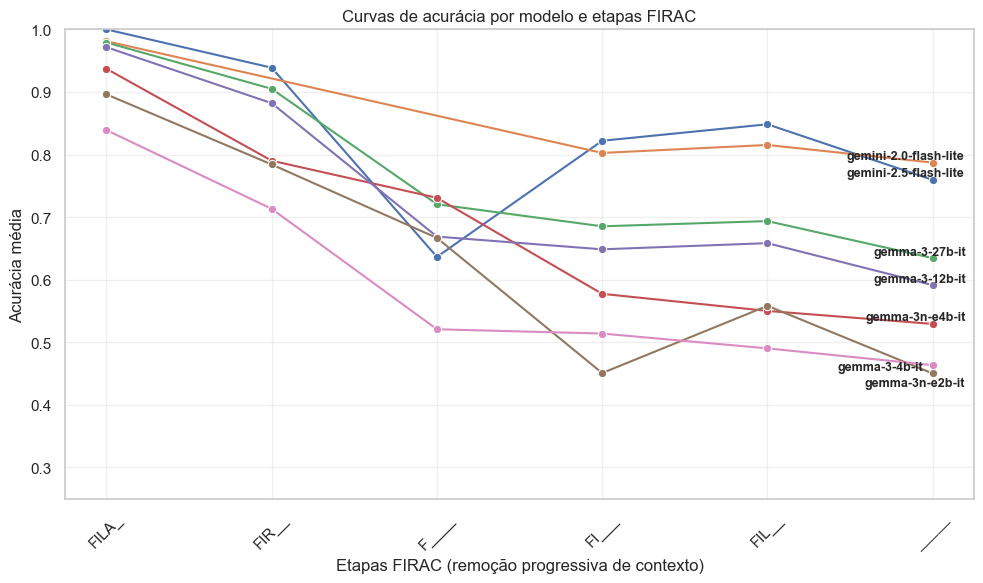

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

# 1. Calcular acurácia média por modelo e firac
curve_data = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .reset_index()
)

# 2. Calcular ordem dos modelos e FIRAC
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)
firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

model_order_accuracy = model_accuracy.index.tolist()
firac_order_accuracy = firac_accuracy.index.tolist()

# 3. Garantir que as colunas sejam categóricas e ordenadas
curve_data["firac"] = pd.Categorical(
    curve_data["firac"], 
    categories=firac_order_accuracy, 
    ordered=True
)
curve_data["model_name"] = pd.Categorical(
    curve_data["model_name"], 
    categories=model_order_accuracy, 
    ordered=True
)

# 4. Plotar as curvas sem legenda
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=curve_data,
    x="firac",
    y="is_correct",
    hue="model_name",
    hue_order=model_order_accuracy,
    marker="o",
    legend=False
)

# 5. Adicionar labels perto das curvas
texts = []
for model in curve_data["model_name"].unique():
    subset = curve_data[curve_data["model_name"] == model]
    last_x = subset["firac"].iloc[-1]
    last_y = subset["is_correct"].iloc[-1]
    texts.append(
        plt.text(
            x=len(firac_order_accuracy) - 1,  # posição no eixo x
            y=last_y,
            s=model,
            fontsize=9,
            fontweight="bold"
        )
    )

# Ajustar automaticamente para evitar sobreposição
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

# 6. Estilização
plt.title("Curvas de acurácia por modelo e etapas FIRAC")
plt.xlabel("Etapas FIRAC (remoção progressiva de contexto)")
plt.ylabel("Acurácia média")
plt.ylim(0.25, 1)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

# -----------------------
# 1. Calcular acurácia média por modelo e firac
# -----------------------
curve_data = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .reset_index()
)

# -----------------------
# 2. Calcular ordem dos modelos e FIRAC
# -----------------------
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)
firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

model_order_accuracy = model_accuracy.index.tolist()
firac_order_accuracy = firac_accuracy.index.tolist()

# -----------------------
# 3. Garantir que as colunas sejam categóricas e ordenadas
# -----------------------
curve_data["firac"] = pd.Categorical(
    curve_data["firac"], 
    categories=firac_order_accuracy, 
    ordered=True
)
curve_data["model_name"] = pd.Categorical(
    curve_data["model_name"], 
    categories=model_order_accuracy, 
    ordered=True
)

# -----------------------
# 4. Calcular AUC (área sob a curva FIRAC) para cada modelo
# -----------------------
auc_df = []

for model in curve_data["model_name"].unique():
    subset = curve_data[curve_data["model_name"] == model].sort_values("firac")
    # Como 'firac' é categórico, usamos índices numéricos igualmente espaçados
    x = np.arange(len(subset))
    y = subset["is_correct"].values
    auc_value = np.trapz(y, x) / (len(x) - 1)  # normalizar entre 0–1 se desejar
    
    # Calcular a acurácia original (firac == "_____")
    acc_original = (
        subset.loc[subset["firac"] == "____", "is_correct"]
        .values[0]
        if "____" in subset["firac"].values else np.nan
    )
    
    auc_df.append({
        "model_name": model,
        "acc_original": acc_original,
        "auc_firac": auc_value,
    })

auc_df = pd.DataFrame(auc_df)

# -----------------------
# 5. Calcular média e desvio-padrão de inconsistências (Guttman) por modelo
# -----------------------
gutmann_stats_df = (
    gutmann_long_df
    .groupby("model_name")["n_inconsistencias"]
    .agg(gutmann_avg_score="mean", gutmann_std_score="std")
    .reset_index()
)

# -----------------------
# 6. Fazer o join com auc_df
# -----------------------
auc_df = auc_df.merge(gutmann_stats_df, on="model_name", how="left")

# -----------------------
# 7. Ordenar pelo AUC (ou pelo Guttman médio, se preferir)
# -----------------------
auc_df = auc_df.sort_values("auc_firac", ascending=False).reset_index(drop=True)

auc_df.head(100)


C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\2571189674.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["model_name", "firac"])["is_correct"]
C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\2571189674.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  question_long_df.groupby("model_name")["is_correct"]
C:\Users\pedro\AppData\Local\Temp\ipykernel_5196\2571189674.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence 

,model_name,acc_original,auc_firac,gutmann_avg_score,gutmann_std_score
0,gemini-2.5-flash-lite,NaN,0.825037,0.125436,0.456056
1,gemma-3-27b-it,NaN,0.762218,0.326516,0.844185
2,gemma-3-12b-it,NaN,0.727814,0.352361,0.835487
3,gemma-3n-e4b-it,NaN,0.676275,0.086632,0.382688
4,gemma-3n-e2b-it,NaN,0.626538,0.099448,0.471767
5,gemma-3-4b-it,NaN,0.577800,0.665956,1.206018
6,gemini-2.0-flash-lite,NaN,NaN,0.176101,0.568527


In [ ]:
auc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model_name         7 non-null      object 
 1   acc_original       0 non-null      float64
 2   auc_firac          6 non-null      float64
 3   gutmann_avg_score  7 non-null      float64
 4   gutmann_std_score  7 non-null      float64
dtypes: float64(4), object(1)
memory usage: 412.0+ bytes


LinAlgError: SVD did not converge in Linear Least Squares

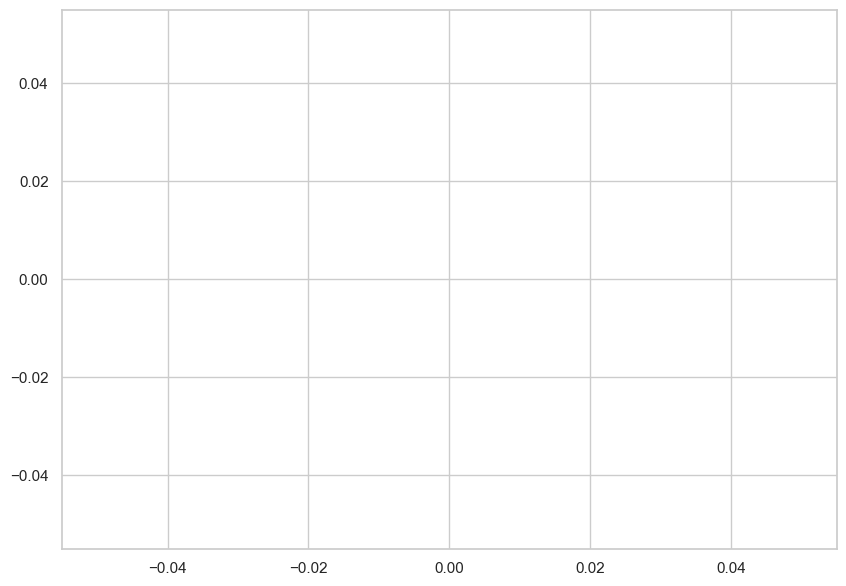

In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

plt.figure(figsize=(10, 7))

# Dados
x = auc_df['auc_firac'].values
y = auc_df['gutmann_avg_score'].values

# Scatter plot
scatter = plt.scatter(
    x, 
    y, 
    c=auc_df['acc_original'], 
    s=150,
    cmap='viridis',
    alpha=0.8,
    edgecolor='k'
)

# Ajuste de uma parábola (polinômio de grau 2)
coeffs = np.polyfit(x, y, deg=2)
parabola = np.poly1d(coeffs)

# Pontos para plotar a parábola
x_parab = np.linspace(x.min(), x.max(), 300)
y_parab = parabola(x_parab)

# Plotar a parábola
plt.plot(x_parab, y_parab, color='red', linestyle='--', linewidth=2, label='Ajuste parabólico')

# Adicionar labels dos modelos com offset
texts = []
offset_x = 0.002
offset_y = 0.002
for i, row in auc_df.iterrows():
    texts.append(
        plt.text(
            row['auc_firac'] + offset_x,
            row['gutmann_avg_score'] + offset_y,
            row['model_name'],
            fontsize=10
        )
    )

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Eixos, título e legenda
plt.xlabel('AUC Firac')
plt.ylabel('Guttman Average Score')
plt.title('Scatter plot de modelos com ajuste parabólico')
plt.colorbar(scatter, label='Acc Original')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

plt.figure(figsize=(10, 7))

# Dados
x = auc_df['acc_original'].values
y = auc_df['gutmann_avg_score'].values

# Scatter plot
scatter = plt.scatter(
    x, 
    y, 
    c=auc_df['acc_original'], 
    s=150,
    cmap='viridis',
    alpha=0.8,
    edgecolor='k'
)

# Ajuste de uma parábola (polinômio de grau 2)
coeffs = np.polyfit(x, y, deg=2)
parabola = np.poly1d(coeffs)

# Pontos para plotar a parábola
x_parab = np.linspace(x.min(), x.max(), 300)
y_parab = parabola(x_parab)

# Plotar a parábola
plt.plot(x_parab, y_parab, color='red', linestyle='--', linewidth=2, label='Ajuste parabólico')

# Adicionar labels dos modelos com offset
texts = []
offset_x = 0.002
offset_y = 0.002
for i, row in auc_df.iterrows():
    texts.append(
        plt.text(
            row['acc_original'] + offset_x,
            row['gutmann_avg_score'] + offset_y,
            row['model_name'],
            fontsize=10
        )
    )

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Eixos, título e legenda
plt.xlabel('Acurácia Original')
plt.ylabel('Guttman Average Score')
plt.title('Scatter plot de modelos com ajuste parabólico')
plt.colorbar(scatter, label='Acc Original')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

plt.figure(figsize=(10, 7))

# Scatter plot
scatter = plt.scatter(
    auc_df['acc_original'], 
    auc_df['auc_firac'], 
    c=auc_df['acc_original'], 
    s=150,
    cmap='viridis',
    alpha=0.8,
    edgecolor='k'
)

# Adicionar labels dos modelos com offset
texts = []
offset_x = 0.002  # ajuste horizontal (direita)
offset_y = 0.002  # ajuste vertical (para cima)

for i, row in auc_df.iterrows():
    texts.append(
        plt.text(
            row['acc_original'] + offset_x, 
            row['auc_firac'] + offset_y, 
            row['model_name'], 
            fontsize=10
        )
    )

# Ajustar texto para não sobrepor
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Eixos e título
plt.xlabel('Acurácia Original')
plt.ylabel('AUC Firac')
plt.colorbar(scatter, label='Acc Original')
plt.grid(True)
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calcular média de inconsistências por questão
question_order = (
    gutmann_long_df
    .groupby("question_id")["n_inconsistencias"]
    .mean()
    .sort_values(ascending=False)  # do maior para o menor
    .index
)

plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Boxplot de inconsistências por questão, ordenado pela média
sns.boxplot(
    data=gutmann_long_df,
    x="question_id",
    y="n_inconsistencias",
    order=question_order,
    color="skyblue"
)

plt.title("Distribuição do número de inconsistências por question_id (ordenado pela média)", fontsize=14, weight="bold")
plt.xlabel("Question ID", fontsize=12)
plt.ylabel("Número de inconsistências", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


# -----------------------
# 1. Transformar para wide format
# -----------------------
# 1. Calcular acurácia média por modelo e firac]

curve_data = (
    question_long_df
    .groupby(["question_id", "firac"])["is_correct"]
    .mean()
    .reset_index()
)


curve_wide = curve_data.pivot(index="question_id", columns="firac", values="is_correct").fillna(0)


# -----------------------
# 2. Clusterizar as curvas semelhantes
# -----------------------
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(curve_wide)

curve_data = curve_data.merge(
    pd.DataFrame({"question_id": curve_wide.index, "cluster": clusters}),
    on="question_id"
)

model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)
firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

model_order_accuracy = model_accuracy.index.tolist()
firac_order_accuracy = firac_accuracy.index.tolist()


# 3. Garantir que as colunas sejam categóricas e ordenadas
curve_data["firac"] = pd.Categorical(
    curve_data["firac"], 
    categories=firac_order_accuracy, 
    ordered=True
)


#curve_data = curve_data.merge(curve_wide["cluster"], on="question_id")


# -----------------------
# 3. Reordenar os clusters com base na média de is_correct
# -----------------------
cluster_means = (
    curve_data.groupby("cluster")["is_correct"]
    .mean()
    .sort_values()
    .reset_index()
)
cluster_order = {old: new for new, old in enumerate(cluster_means["cluster"])}
curve_data["cluster"] = curve_data["cluster"].map(cluster_order)

# -----------------------
# 4. Função para plotar curvas individuais + média
# -----------------------
def plot_cluster_data(data, **kwargs):
    sns.lineplot(
        data=data,
        x="firac", y="is_correct",
        hue="question_id",
        alpha=0.4, lw=1, legend=False
    )
    mean_curve = data.groupby("firac")["is_correct"].mean().reset_index()
    sns.lineplot(
        data=mean_curve,
        x="firac", y="is_correct",
        color="black", lw=3
    )

# -----------------------
# 5. Visualizar clusters individualmente (FacetGrid)
# -----------------------
g = sns.FacetGrid(
    curve_data,
    col="cluster",
    col_wrap=3,
    height=3,
    sharey=True
)
g.map_dataframe(plot_cluster_data)
g.set_titles("Cluster {col_name}")

# Rotacionar labels do eixo X
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# -----------------------
# 6. Novo gráfico: curvas médias dos 3 clusters com erro padrão
# -----------------------

# Calcular média e erro padrão por cluster e firac
summary = (
    curve_data.groupby(["cluster", "firac"])["is_correct"]
    .agg(["mean", "sem"])  # sem = standard error of the mean
    .reset_index()
)

# Plotar todas as curvas juntas
plt.figure(figsize=(7, 5))
sns.lineplot(
    data=summary,
    x="firac", y="mean",
    hue="cluster",
    linewidth=2.5,
    err_style="band",
    err_kws={"alpha": 0.2},
)

# Adicionar bandas de erro manualmente (para mais controle visual)
for cluster_id, cluster_df in summary.groupby("cluster"):
    plt.fill_between(
        cluster_df["firac"],
        cluster_df["mean"] - cluster_df["sem"],
        cluster_df["mean"] + cluster_df["sem"],
        alpha=0.2
    )

plt.title("Clusters de questões por perfil cognitivo")
plt.xlabel("FIRAC")
plt.ylabel("Acurácia")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

question_cluster_df = curve_data[["question_id", "cluster"]].drop_duplicates().reset_index(drop=True)



In [ ]:
question_cluster_df.head()

In [ ]:
# -----------------------
# Merge question_agg_df com question_cluster_df
# -----------------------
question_summary_df = question_agg_df.merge(
    question_cluster_df,
    on="question_id",
    how="left"
)

# Visualizar as primeiras linhas
question_summary_df.tail()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# 1. Definir as colunas a analisar
# -----------------------
cols_to_plot = ["accuracy", "question_body_length", "rule_count", "response_time_seconds"]

# -----------------------
# 2. Criar os boxplots
# -----------------------
plt.figure(figsize=(12, 8))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=question_summary_df, x="cluster", y=col)
    plt.title(f"Distribuição de {col} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.tight_layout()

plt.show()


In [ ]:
# 1. Calcular acurácia média por combinação model_name + firac
accuracy_order = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .sort_values(ascending=True)
)

# 2. Pivotar para o formato wide
question_wide_df = (
    question_long_df
    .pivot_table(
        index="question_id",
        columns=["model_name", "firac"],
        values="is_correct"
    )
)

# 3. Reordenar as colunas conforme a acurácia calculada
question_wide_df = question_wide_df[accuracy_order.index]

# 4. Flatten do MultiIndex nas colunas
question_wide_df.columns = [
    f"{model}_{firac}" for model, firac in question_wide_df.columns
]

# 5. Resetar o índice (opcional)
question_wide_df = question_wide_df.reset_index()

#question_wide_df = question_wide_df.dropna(axis=1, how="any")

question_wide_df.head()


In [ ]:
pd.set_option('display.max_rows', None)


# Conta o número de valores NaN por coluna
na_counts = question_wide_df.isna().sum()

# Mostra o resultado ordenado do maior para o menor
na_counts.sort_values(ascending=False)

In [ ]:
# Mantém apenas as colunas que começam com 'gemini'
question_wide_df = question_wide_df.filter(regex=r'^gemini')

# Verifica o resultado
question_wide_df.head()
question_wide_df = question_wide_df.dropna()

question_wide_df.head()

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

pd.set_option('display.max_columns', None)


# 1. Separar apenas as colunas numéricas
X = question_wide_df.select_dtypes(include="number")

# 2. Definir o número de clusters
n_clusters = 2

# 3. Rodar o K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
question_wide_df["cluster"] = kmeans.fit_predict(X)

# 4. Criar um DataFrame dos centróides
cluster_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns,
    index=[f"Cluster {i}" for i in range(n_clusters)]
)

# 5. Adicionar uma coluna com o tamanho de cada cluster
cluster_sizes = question_wide_df["cluster"].value_counts().sort_index()
cluster_df["size"] = cluster_sizes.values

# 6. Mostrar o resultado arredondado para melhor visualização
cluster_df = cluster_df.round(3)
cluster_df.head()


In [ ]:
import pandas as pd
import numpy as np

# 1. Criar matriz: linhas = provas (ou observações), colunas = question_id, valores = is_correct
#    Se quisermos alpha para todo o exame, podemos agregar por prova ou usar todas as respostas juntas.
exam_matrix = question_long_df.pivot_table(
    index='pdf_filename',       # ou outro identificador de observação
    columns='question_id',
    values='is_correct'
)

# 2. Função para calcular alpha de Cronbach
def cronbach_alpha(df):
    df = df.dropna(axis=1, how='all')  # remover colunas sem dados
    k = df.shape[1]                     # número de itens
    item_var = df.var(axis=0, ddof=1)   # variância de cada item
    total_var = df.sum(axis=1).var(ddof=1)  # variância total da soma
    alpha = (k / (k-1)) * (1 - item_var.sum() / total_var)
    return alpha

# 3. Calcular alpha
alpha_exam = cronbach_alpha(exam_matrix)
print("Alpha de Cronbach do exame:", alpha_exam)
